# 

## Introduction 

### Andrés González Ojeda 31612
This activity consists on training a model to serialize it and deploy it on an application.

The dataset chosen for this activity is Twitter Sentiment Analysis in Spanish Tweets. Where the goal is to predict either the sentiment or the emotion of a given short text or 'Tweet' in Spanish. This makes this a text classification multiclass single-label problem.

The serialization will be done with ONNX since we want to create a web application with node.js.

The dataset was sourced from: https://www.kaggle.com/datasets/philipsanm/sentiment-analysis-in-spanish-tweets/data



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

We can see that we have very few variables, and many of them aren't useful.

In [3]:
data = pd.read_csv('../data/sentiment_analysis_dataset.csv')
data

,user,text,date,emotion,sentiment
0,@erreborda,termine bien abrumado después de hoy,"Jan 6, 2024 · 2:53 AM UTC",overwhelmed,scared
1,@shpiderduck,me siento abrumado,"Jan 6, 2024 · 2:35 AM UTC",overwhelmed,scared
2,@Alex_R_art,Me siento un poco abrumado por la cantidad de ...,"Jan 6, 2024 · 12:20 AM UTC",overwhelmed,scared
3,@anggelinaa97,Salvador la única persona que no la ha abrumad...,"Jan 5, 2024 · 10:38 PM UTC",overwhelmed,scared
4,@diegoreyesvqz,Denme un helado o algo que ando full abrumado.,"Jan 5, 2024 · 8:38 PM UTC",overwhelmed,scared
...,...,...,...,...,...
2585,@lavivianaleyva,No podemos vivir con miedo: ¡Manejen borrach...,"Jan 6, 2024 · 3:08 AM UTC",daring,joyful
2586,@Carmeen_Alicia,"La vida es un constante, SIN MIEDO AL ÉXITO 💅🏼","Jan 6, 2024 · 3:07 AM UTC",daring,joyful
2587,@homicidios_,Esquizofrenia = mente dividida: Miedo a las re...,"Jan 6, 2024 · 2:59 AM UTC",daring,joyful
2588,@brigethcoba,"""Lo que más miedo me da, es ver cómo desaparec...","Jan 6, 2024 · 2:55 AM UTC",daring,joyful


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2590 entries, 0 to 2589
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user       2590 non-null   str  
 1   text       2590 non-null   str  
 2   date       2590 non-null   str  
 3   emotion    2590 non-null   str  
 4   sentiment  2590 non-null   str  
dtypes: str(5)
memory usage: 101.3 KB


In [5]:
data.describe().T

,count,unique,top,freq
user,2590,2083,@joselinconjota,12
text,2590,2191,"Para entender el mundo, lee. Para entenderte ...",6
date,2590,949,"Jan 6, 2024 · 3:38 AM UTC",25
emotion,2590,20,sleepy,150
sentiment,2590,6,peaceful,660


We can see that we don't have any empty registers, so we don't have to worry due to lack of data

In [6]:
data.isna().sum()

user         0
text         0
date         0
emotion      0
sentiment    0
dtype: int64

## Column description
From our five columns user and date need to be dropped since they are not important features, they're just metadata. 

Our only feature will bw the text, making this an interesting challenge.

Our two possible labels are emotion and sentiment, we'll explore them a little more.

In [7]:
data.drop(columns=['user', 'date'])

,text,emotion,sentiment
0,termine bien abrumado después de hoy,overwhelmed,scared
1,me siento abrumado,overwhelmed,scared
2,Me siento un poco abrumado por la cantidad de ...,overwhelmed,scared
3,Salvador la única persona que no la ha abrumad...,overwhelmed,scared
4,Denme un helado o algo que ando full abrumado.,overwhelmed,scared
...,...,...,...
2585,No podemos vivir con miedo: ¡Manejen borrach...,daring,joyful
2586,"La vida es un constante, SIN MIEDO AL ÉXITO 💅🏼",daring,joyful
2587,Esquizofrenia = mente dividida: Miedo a las re...,daring,joyful
2588,"""Lo que más miedo me da, es ver cómo desaparec...",daring,joyful


In [ ]:
corr_matrix = data.corr()
plt.figure(figsize=(10, 8))

As we can see emotion 

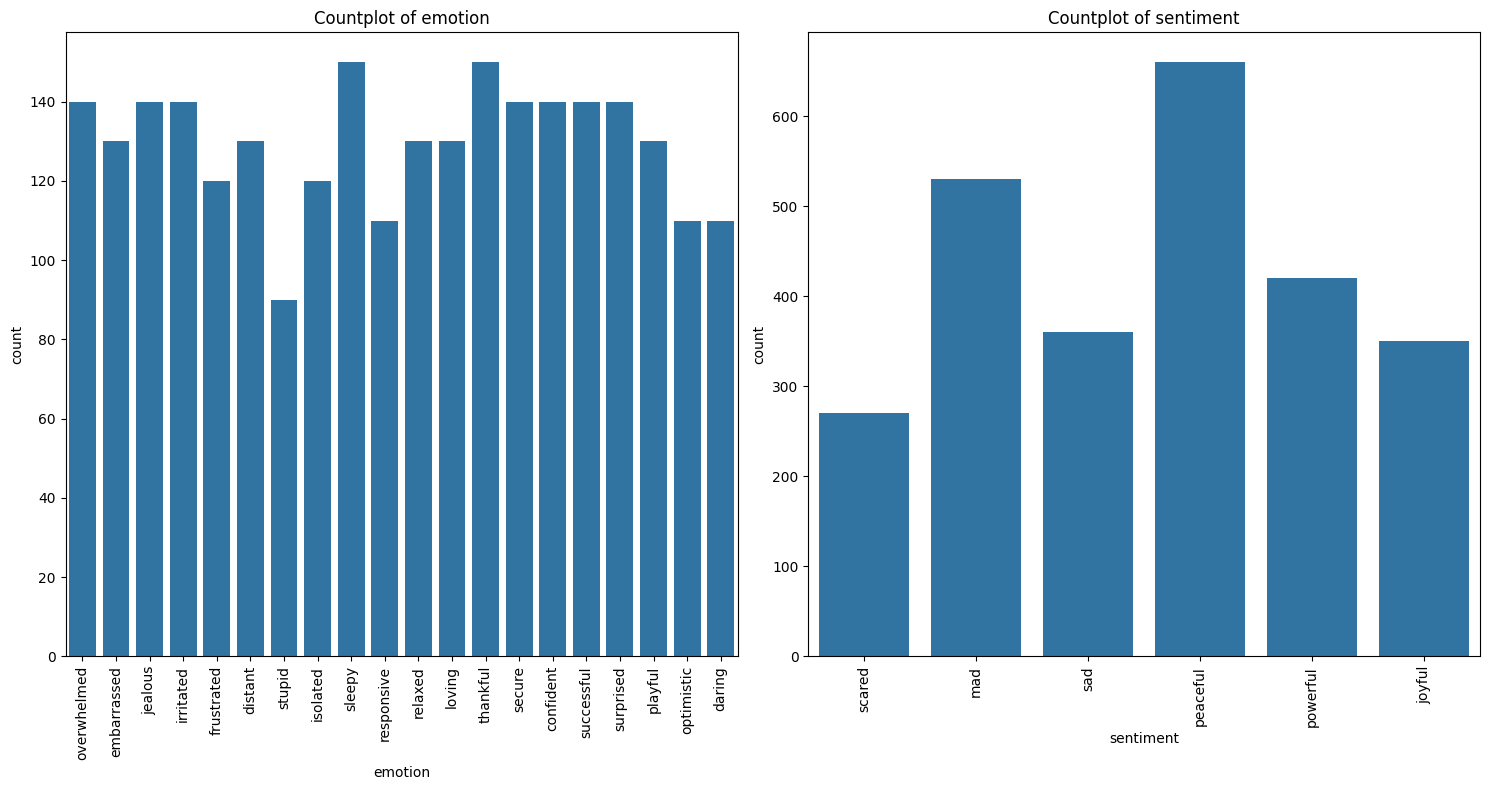

In [8]:
target_cols = ['emotion', 'sentiment']
fig, axs = plt.subplots(1, 2, figsize=(15, 8))
for ax, col in zip(axs.ravel(), target_cols):
    sns.countplot(data=data, x=col, ax=ax)
    ax.set_title(f'Countplot of {col}')
    ax.tick_params(axis='x', rotation=90)
fig.tight_layout()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

X = data['text']
y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    metrics = {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, average='weighted'),
        'Recall': recall_score(y, y_pred, average='weighted'),
        'F1 Score': f1_score(y, y_pred, average='weighted')
    }
    return metrics

In [10]:
# Model 1 - Multinomial Naive Bayes pipeline
nb_pipe = make_pipeline(
    CountVectorizer(),
    MultinomialNB()
)
nb_param_grid = {
    'multinomialnb__alpha': [0.01, 0.1, 0.5, 1.0]
}
nb_grid_search = GridSearchCV(
    estimator=nb_pipe,
    param_grid=nb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
nb_grid_search.fit(X_train, y_train)
print(f"\nBest parameters: {nb_grid_search.best_params_}")
print(f"Best accuracy score cross validation: {nb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best parameters: {'multinomialnb__alpha': 0.1}
Best accuracy score cross validation: 0.5594


In [11]:
nb_best_model = nb_grid_search.best_estimator_
nb_train_metrics = evaluate_model(nb_best_model, X_train, y_train)
nb_test_metrics = evaluate_model(nb_best_model, X_test, y_test)
print("\nMultinomial Naive Bayes Performance:")
print(pd.DataFrame([nb_train_metrics, nb_test_metrics], index=['Train', 'Test']))


Multinomial Naive Bayes Performance:
       Accuracy  Precision    Recall  F1 Score
Train  0.932915   0.936264  0.932915  0.933340
Test   0.592664   0.591792  0.592664  0.591365


In [12]:
y_pred_nb = nb_best_model.predict(X_test)
print("\nClassification Report (MultinomialNB):")
print(classification_report(y_test, y_pred_nb))


Classification Report (MultinomialNB):
              precision    recall  f1-score   support

      joyful       0.53      0.44      0.48        61
         mad       0.65      0.65      0.65       106
    peaceful       0.62      0.65      0.64       135
    powerful       0.57      0.53      0.55        92
         sad       0.52      0.57      0.55        68
      scared       0.59      0.62      0.61        56

    accuracy                           0.59       518
   macro avg       0.58      0.58      0.58       518
weighted avg       0.59      0.59      0.59       518



In [13]:
# Model 2 - LinearSVC pipeline
svc_pipe = make_pipeline(
    CountVectorizer(),
    LinearSVC()
)
svc_param_grid = {
    'linearsvc__C': [0.01, 0.1, 1, 10]
}
svc_grid_search = GridSearchCV(
    estimator=svc_pipe,
    param_grid=svc_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
svc_grid_search.fit(X_train, y_train)
print(f"\nBest parameters (LinearSVC): {svc_grid_search.best_params_}")
print(f"Best accuracy score cross validation (LinearSVC): {svc_grid_search.best_score_:.4f}")

svc_best_model = svc_grid_search.best_estimator_
svc_train_metrics = evaluate_model(svc_best_model, X_train, y_train)
svc_test_metrics = evaluate_model(svc_best_model, X_test, y_test)
print("\nLinearSVC Performance:")
print(pd.DataFrame([svc_train_metrics, svc_test_metrics], index=['Train', 'Test']))

y_pred_svc = svc_best_model.predict(X_test)
print("\nClassification Report (LinearSVC):")
print(classification_report(y_test, y_pred_svc))

Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\Users\spisi\Documents\repos\computer-inteligence\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Best parameters (LinearSVC): {'linearsvc__C': 1}
Best accuracy score cross validation (LinearSVC): 0.6955

LinearSVC Performance:
       Accuracy  Precision    Recall  F1 Score
Train  0.937259   0.937710  0.937259  0.937284
Test   0.750965   0.751754  0.750965  0.750971

Classification Report (LinearSVC):
              precision    recall  f1-score   support

      joyful       0.67      0.66      0.66        61
         mad       0.81      0.75      0.77       106
    peaceful       0.78      0.79      0.78       135
    powerful       0.74      0.76      0.75        92
         sad       0.69      0.71      0.70        68
      scared       0.77      0.82      0.79        56

    accuracy                           0.75       518
   macro avg       0.74      0.75      0.74       518
weighted avg       0.75      0.75      0.75       518



Scikit-learn documentation — Text feature extraction explicitly states that TF-IDF weighting is useful to re-weight features that appear too frequently and are less informative.

TfidfVectorizer instead of CountVectorizer — weighs rare but important words higher, reduces noise from frequent words
ngram_range=(1, 2) — captures both single words and two-word phrases ("no good", "very happy"), giving the model much more context
sublinear_tf tuned in GridSearch — log-scales term frequency, which further helps with imbalanced word distributions
max_features tuned — limits vocabulary size for regularization

https://scikit-learn.org/stable/modules/feature_extraction.html#tfidf-term-weighting

In [14]:
# Model 3 - Logistic Regression with TF-IDF + bigrams
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

lr_pipe = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2)),  # unigrams + bigrams
    LogisticRegression(max_iter=1000)
)
lr_param_grid = {
    'tfidfvectorizer__max_features': [5000, 20000, None],
    'tfidfvectorizer__sublinear_tf': [True, False],
    'logisticregression__C': [0.1, 1, 10],
}
lr_grid_search = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
lr_grid_search.fit(X_train, y_train)
print(f"\nBest parameters (LogisticRegression+TF-IDF): {lr_grid_search.best_params_}")
print(f"Best accuracy score cross validation: {lr_grid_search.best_score_:.4f}")

lr_best_model = lr_grid_search.best_estimator_
lr_train_metrics = evaluate_model(lr_best_model, X_train, y_train)
lr_test_metrics = evaluate_model(lr_best_model, X_test, y_test)
print("\nLogistic Regression + TF-IDF Performance:")
print(pd.DataFrame([lr_train_metrics, lr_test_metrics], index=['Train', 'Test']))

y_pred_lr = lr_best_model.predict(X_test)
print("\nClassification Report (LogisticRegression+TF-IDF):")
print(classification_report(y_test, y_pred_lr))

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters (LogisticRegression+TF-IDF): {'logisticregression__C': 10, 'tfidfvectorizer__max_features': 5000, 'tfidfvectorizer__sublinear_tf': True}
Best accuracy score cross validation: 0.6332

Logistic Regression + TF-IDF Performance:
       Accuracy  Precision    Recall  F1 Score
Train  0.936293   0.936456  0.936293  0.936245
Test   0.677606   0.678929  0.677606  0.676290

Classification Report (LogisticRegression+TF-IDF):
              precision    recall  f1-score   support

      joyful       0.63      0.54      0.58        61
         mad       0.71      0.72      0.71       106
    peaceful       0.66      0.76      0.71       135
    powerful       0.67      0.63      0.65        92
         sad       0.64      0.63      0.64        68
      scared       0.78      0.68      0.72        56

    accuracy                           0.68       518
   macro avg       0.68      0.66      0.67       518
weighted avg    

In [15]:
# Examples for every sentiment: joyful, mad, peaceful, powerful, sad, scared
examples = [
    ("Hoy recibí una noticia maravillosa y no puedo dejar de sonreír.", "joyful"),
    ("Perdí mi cartera y nadie quiso ayudarme, estoy muy frustrado.", "mad"),
    ("Escuchando la lluvia desde mi ventana, todo está en calma.", "peaceful"),
    ("Logré superar todos los obstáculos y ahora siento que nada me detiene.", "powerful"),
    ("Extraño mucho a mi familia y me siento solo esta noche.", "sad"),
    ("Escuché ruidos extraños afuera y no me atrevo a salir de mi cuarto.", "scared")
]

for text, real_sentiment in examples:
    prediction_label = lr_best_model.predict([text])
    print(f"Text: {text}\nSentimiento real: {real_sentiment}\nPredicted sentiment: {prediction_label[0]}\n")

Text: Hoy recibí una noticia maravillosa y no puedo dejar de sonreír.
Sentimiento real: joyful
Predicted sentiment: peaceful

Text: Perdí mi cartera y nadie quiso ayudarme, estoy muy frustrado.
Sentimiento real: mad
Predicted sentiment: mad

Text: Escuchando la lluvia desde mi ventana, todo está en calma.
Sentimiento real: peaceful
Predicted sentiment: peaceful

Text: Logré superar todos los obstáculos y ahora siento que nada me detiene.
Sentimiento real: powerful
Predicted sentiment: peaceful

Text: Extraño mucho a mi familia y me siento solo esta noche.
Sentimiento real: sad
Predicted sentiment: mad

Text: Escuché ruidos extraños afuera y no me atrevo a salir de mi cuarto.
Sentimiento real: scared
Predicted sentiment: sad



## Deploying the model to onnx

In [ ]:
# from skl2onnx import to_onnx
# from skl2onnx.common.data_types import StringTensorType

# # Export Logistic Regression pipeline (skl2onnx fully supported + stronger than NB)
# initial_type = [('string_input', StringTensorType([None, 1]))]
# onx = to_onnx(lr_best_model, initial_types=initial_type)

# with open("models/sentiment_model.onnx", "wb") as f:
#     f.write(onx.SerializeToString())

# print("Model exported to models/sentiment_model.onnx")

Model exported to models/sentiment_model.onnx


In [19]:
from skl2onnx import to_onnx
from skl2onnx.common.data_types import StringTensorType
#from skl2onnx.proto import onnx_proto

initial_type = [('string_input', StringTensorType([None, 1]))]
onx = to_onnx(
    lr_best_model, 
    initial_types=initial_type,
    target_opset=12,
    options={id(lr_best_model): {'zipmap': False}}  # This forces tensor output instead of map
)

with open("models/sentiment_model.onnx", "wb") as f:
    f.write(onx.SerializeToString())

print("Model exported to models/sentiment_model.onnx")

Model exported to models/sentiment_model.onnx
